# Does `s_nom=0` drop an AC line from the KVL?

**Question.** When a grid-scenario override sets an AC line's capacity to zero, does PyPSA silently remove that line's Kirchhoff-Voltage-Law (KVL) constraint from the optimisation model? If it did, scenarios that differ only in `s_nom` would carry *different* model structures - a problem for a stochastic program that must share one recourse structure.

**Method.** Build the [`ac-dc-lopf` example network](https://docs.pypsa.org/v1.0.3/examples/ac-dc-lopf/) (`pypsa.examples.ac_dc_meshed()`), create the LP model, and read back:
- the shape of `n.cycle_matrix(...)` (branches x independent cycles),
- the number of live `Kirchhoff-Voltage-Law` constraints in `n.model`, and
- the cycle matrix reconstructed **directly from `n.model`** (the KVL constraint's `coeffs`/`vars`), to confirm its row count is unchanged.

Compare four tweaks to one line that sits in a cycle: baseline, `s_nom=0`, `s_max_pu=0`, and `x=inf`. If the count is unchanged, the equation is **not** dropped.

*Run with* `pixi run jupyter lab` *(or the VSCode Jupyter extension) using the project's `pixi` env.*

In [1]:
import warnings

import pandas as pd
import pypsa

warnings.filterwarnings("ignore")
print("pypsa", pypsa.__version__)

LINE = "2"  # an AC line that belongs to a cycle in the example


def build(modify=None, line=LINE):
    """AC-DC meshed example with an optional in-place tweak, LP model created."""
    n = pypsa.examples.ac_dc_meshed()
    if modify is not None:
        modify(n, line)
    n.optimize.create_model()
    return n


def kvl_stats(n, line=LINE):
    """Number of cycles, live KVL constraints, and whether the line stays in a cycle."""
    C = n.cycle_matrix(apply_weights=True)
    kvl = n.model.constraints["Kirchhoff-Voltage-Law"]
    n_con = int((kvl.labels.values >= 0).sum())
    in_cycle = ("Line", line) in C.index and bool((C.loc[("Line", line)] != 0).any())
    return {"cycles": C.shape[1], "kvl_constraints": n_con, "line_in_cycle": in_cycle}


def model_cycle_matrix(n, snapshot=0):
    """Reconstruct the cycle matrix straight from the KVL constraint in ``n.model``.

    The linopy constraint stores coefficients with dims (snapshot, cycle, _term);
    the ``_term`` axis holds the branch variables. Mapping each variable label back
    to its branch name yields a (branch x cycle) matrix - the cycle matrix as the
    solver actually sees it, independent of the ``n.cycle_matrix`` helper.
    """
    con = n.model.constraints["Kirchhoff-Voltage-Law"]
    coe = con.coeffs.isel(snapshot=snapshot)
    var = con.vars.isel(snapshot=snapshot)
    lab2name = {}
    for vname in ("Line-s", "Link-p"):
        if vname not in n.model.variables:
            continue
        v = n.model.variables[vname].labels.isel(snapshot=snapshot)
        for name, lab in zip(v["name"].values, v.values):
            lab2name[int(lab)] = f"{vname.split('-')[0]}:{name}"
    rows: dict = {}
    for c in range(coe.sizes["cycle"]):
        for lab, cf in zip(var.isel(cycle=c).values, coe.isel(cycle=c).values):
            lab = int(lab)
            if lab < 0:  # linopy pads shorter cycles with -1 / 0
                continue
            rows.setdefault(lab2name[lab], {})[c] = float(cf)
    return pd.DataFrame(rows).T.reindex(columns=range(coe.sizes["cycle"])).fillna(0.0).sort_index()

pypsa 1.2.4


## 1. Deterministic check

One line, four states. `s_nom=0` and `s_max_pu=0` both force the line's flow to zero; `x=inf` makes its impedance infinite.

In [2]:
def set_s_nom0(n, line):
    n.lines.loc[line, "s_nom"] = 0.0


def set_s_max_pu0(n, line):
    n.lines.loc[line, "s_max_pu"] = 0.0


def set_x_inf(n, line):
    n.lines.loc[line, "x"] = float("inf")


cases = {
    "base": None,
    "s_nom=0": set_s_nom0,
    "s_max_pu=0": set_s_max_pu0,
    "x=inf": set_x_inf,
}

results = pd.DataFrame(
    {name: kvl_stats(build(mod)) for name, mod in cases.items()}
).T
results

INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.4)
INFO:pypsa.network.io:Imported network 'AC-DC-Meshed' has buses, carriers, generators, global_constraints, lines, links, loads
Index(['2', '3', '4'], dtype='object', name='name')
Index(['0', '1', '5', '6'], dtype='object', name='name')
INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.4)
INFO:pypsa.network.io:Imported network 'AC-DC-Meshed' has buses, carriers, generators, global_constraints, lines, links, loads
Index(['2', '3', '4'], dtype='object', name='name')
Index(['0', '1', '5', '6'], dtype='object', name='name')
INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.4)
INFO:pypsa.network.io:Imported network 'AC-DC-Meshed' has buses, carriers, generators, global_constraints, lines, links, loads
Index(['2', '3', '4'], dtype='object', name='name')
Index(['0', '1', '5', '6'], dtype='object', name='name')
INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.4)
INFO:pypsa.network.i

,cycles,kvl_constraints,line_in_cycle
base,2,20,True
s_nom=0,2,20,True
s_max_pu=0,2,20,True
x=inf,1,10,False


In [3]:
base = results.loc["base", "kvl_constraints"]
assert results.loc["s_nom=0", "kvl_constraints"] == base, "s_nom=0 changed the KVL!"
assert results.loc["s_max_pu=0", "kvl_constraints"] == base, "s_max_pu=0 changed the KVL!"
assert results.loc["x=inf", "kvl_constraints"] < base, "x=inf did NOT drop the cycle!"
print("PASS: s_nom=0 and s_max_pu=0 keep the KVL intact; only x=inf drops the line.")

PASS: s_nom=0 and s_max_pu=0 keep the KVL intact; only x=inf drops the line.


### Interpretation

- `base`, `s_nom=0`, `s_max_pu=0` give the **same** cycle count and the **same** number of KVL constraints, and the line stays in its cycle. The equation is **not** dropped - the line still participates in KVL with its finite reactance, its flow simply pinned to zero. This is the *phantom cycle*.
- Only `x=inf` removes the line from the cycle basis (fewer cycles, fewer KVL rows). Electrically "removing" an AC line needs infinite impedance, not zero capacity.
- **`s_max_pu=0` is therefore not safer than `s_nom=0` for this concern** - both behave identically w.r.t. KVL.

## 2. Cycle matrix read straight from `n.model`

The check above uses the `n.cycle_matrix` helper. To be sure the *solver's* model is unchanged, reconstruct the cycle matrix directly from the `Kirchhoff-Voltage-Law` constraint in `n.model` - its `coeffs`/`vars` arrays - and compare row-by-row for `base` vs `s_nom=0`.

In [4]:
C_base = model_cycle_matrix(build())
C_zero = model_cycle_matrix(build(set_s_nom0))

print("cycle matrix from n.model  -  base       :", C_base.shape, "(rows=branches, cols=cycles)")
print("cycle matrix from n.model  -  s_nom=0    :", C_zero.shape)
print("same branch rows?", list(C_base.index) == list(C_zero.index))
print("matrices identical?", C_base.equals(C_zero))

line_row = f"Line:{LINE}"
kept = line_row in C_zero.index and bool((C_zero.loc[line_row] != 0).any())
print(f"{line_row} still carries a nonzero KVL coefficient at s_nom=0?", kept)

assert C_base.shape[0] == C_zero.shape[0], "row count changed - a branch was dropped!"
assert C_base.equals(C_zero), "coefficients changed - model is not identical!"
assert kept, "zeroed line lost its KVL coefficient!"
print("\nPASS: n.model's cycle matrix has identical rows; the s_nom=0 line stays in the KVL.")
C_zero

INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.4)
INFO:pypsa.network.io:Imported network 'AC-DC-Meshed' has buses, carriers, generators, global_constraints, lines, links, loads
Index(['2', '3', '4'], dtype='object', name='name')
Index(['0', '1', '5', '6'], dtype='object', name='name')
INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.4)
INFO:pypsa.network.io:Imported network 'AC-DC-Meshed' has buses, carriers, generators, global_constraints, lines, links, loads
Index(['2', '3', '4'], dtype='object', name='name')
Index(['0', '1', '5', '6'], dtype='object', name='name')


cycle matrix from n.model  -  base       : (7, 2) (rows=branches, cols=cycles)
cycle matrix from n.model  -  s_nom=0    : (7, 2)
same branch rows? True
matrices identical? True
Line:2 still carries a nonzero KVL coefficient at s_nom=0? True

PASS: n.model's cycle matrix has identical rows; the s_nom=0 line stays in the KVL.


,0,1
Line:0,-0.551855,0.000000
Line:1,-0.271163,0.000000
Line:2,0.000000,-0.531510
Line:3,0.000000,-1.215409
Line:4,0.000000,-1.071817
Line:5,-0.165374,0.000000
Line:6,0.000000,0.000000


## 3. Stochastic check

Two scenarios sharing one topology; the line is zeroed in the `cut` scenario only. If the KVL were dropped where `s_nom=0`, the `cut` scenario would carry fewer constraints than `full`. It does not: the constraint spans a full `(scenario, snapshot, cycle)` grid.

In [5]:
n = pypsa.examples.ac_dc_meshed()
n.set_scenarios({"full": 0.5, "cut": 0.5})
n.lines.loc[("cut", LINE), "s_nom"] = 0.0
n.optimize.create_model()

kvl = n.model.constraints["Kirchhoff-Voltage-Law"]
print("scenarios:", list(n.scenarios))
print("KVL dims :", kvl.labels.dims)
print("KVL shape:", kvl.labels.shape, "(scenario, snapshot, cycle)")

n_cycles = kvl.labels.shape[kvl.labels.dims.index("cycle")]
assert n_cycles == 2, "cut scenario lost a cycle - KVL was dropped!"
print("\nPASS: both scenarios carry identical KVL structure (2 cycles each).")

INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.4)
INFO:pypsa.network.io:Imported network 'AC-DC-Meshed' has buses, carriers, generators, global_constraints, lines, links, loads
MultiIndex([('full', '2'),
            ('full', '3'),
            ('full', '4'),
            ( 'cut', '2'),
            ( 'cut', '3'),
            ( 'cut', '4')],
           names=['scenario', 'name'])
MultiIndex([('full', '0'),
            ('full', '1'),
            ('full', '5'),
            ('full', '6'),
            ( 'cut', '0'),
            ( 'cut', '1'),
            ( 'cut', '5'),
            ( 'cut', '6')],
           names=['scenario', 'name'])


scenarios: ['full', 'cut']
KVL dims : ('scenario', 'snapshot', 'cycle')
KVL shape: (2, 10, 2) (scenario, snapshot, cycle)

PASS: both scenarios carry identical KVL structure (2 cycles each).


## 4. Which reactances does the stochastic KVL use?

The cycle matrix is shared across scenarios (Section 3), but *whose* reactances weight it? PyPSA builds the weighted cycle matrix from `scenarios[0]` only (`networks.py` `cycle_matrix` / `find_cycles`). Prove it: give one AC line a **different reactance in each scenario** and read back the coefficient the model actually applies per scenario. If every scenario shows the first scenario's value - and swapping the order flips that value - then `scenarios[0]` governs the electrical model for all scenarios.

In [6]:
import numpy as np


def kvl_coeff(n, scenario, line, snapshot=0):
    """The coefficient the model applies to `line`'s flow in one scenario's KVL row."""
    con = n.model.constraints["Kirchhoff-Voltage-Law"]
    lab = int(
        n.model.variables["Line-s"]
        .labels.sel(scenario=scenario)
        .isel(snapshot=snapshot)
        .sel(name=line)
        .values
    )
    coe = con.coeffs.sel(scenario=scenario).isel(snapshot=snapshot).values
    var = con.vars.sel(scenario=scenario).isel(snapshot=snapshot).values
    return float(coe[var == lab].sum())


def two_scenario_coeffs(line, x_first, x_second):
    """2-scenario network giving `line` a different reactance in each scenario."""
    n = pypsa.examples.ac_dc_meshed()
    n.set_scenarios({"first": 0.5, "second": 0.5})
    n.lines.loc[("first", line), "x"] = x_first
    n.lines.loc[("second", line), "x"] = x_second
    n.optimize.create_model()
    return kvl_coeff(n, "first", line), kvl_coeff(n, "second", line)


AC_LINE = "5"  # an AC-subnetwork line, so its KVL weight is the reactance x
x0 = 0.2388    # its base reactance

order_A = two_scenario_coeffs(AC_LINE, x_first=x0, x_second=10 * x0)
order_B = two_scenario_coeffs(AC_LINE, x_first=10 * x0, x_second=x0)

print(f"order A  first x={x0:>6}, second x={10 * x0:>6}  ->  KVL coeffs (first, second) = "
      f"({order_A[0]:.6f}, {order_A[1]:.6f})")
print(f"order B  first x={10 * x0:>6}, second x={x0:>6}  ->  KVL coeffs (first, second) = "
      f"({order_B[0]:.6f}, {order_B[1]:.6f})")

assert np.isclose(*order_A), "scenarios disagree in order A - weights not shared!"
assert np.isclose(*order_B), "scenarios disagree in order B - weights not shared!"
assert np.isclose(order_B[0], 10 * order_A[0]), "coefficient does not track scenarios[0]!"
print("\nPASS: every scenario's KVL uses scenarios[0]'s reactance; the second "
      "scenario's own reactance is ignored.")

INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.4)
INFO:pypsa.network.io:Imported network 'AC-DC-Meshed' has buses, carriers, generators, global_constraints, lines, links, loads
MultiIndex([( 'first', '2'),
            ( 'first', '3'),
            ( 'first', '4'),
            ('second', '2'),
            ('second', '3'),
            ('second', '4')],
           names=['scenario', 'name'])
MultiIndex([( 'first', '0'),
            ( 'first', '1'),
            ( 'first', '5'),
            ( 'first', '6'),
            ('second', '0'),
            ('second', '1'),
            ('second', '5'),
            ('second', '6')],
           names=['scenario', 'name'])
INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.4)
INFO:pypsa.network.io:Imported network 'AC-DC-Meshed' has buses, carriers, generators, global_constraints, lines, links, loads
MultiIndex([( 'first', '2'),
            ( 'first', '3'),
            ( 'first', '4'),
            ('second', '2'),
        

order A  first x=0.2388, second x= 2.388  ->  KVL coeffs (first, second) = (-0.165374, -0.165374)
order B  first x= 2.388, second x=0.2388  ->  KVL coeffs (first, second) = (-1.653740, -1.653740)

PASS: every scenario's KVL uses scenarios[0]'s reactance; the second scenario's own reactance is ignored.


## 5. Magnitude of the reactance-not-scaling error (toy model)

Sections 1-4 ask whether the KVL is *present*; this asks how *wrong* it is when a corridor's capacity is raised but its reactance is left unchanged (what an `s_nom`-only override does).

A 3-bus loop isolates the effect. Cheap generation at bus 1 (1 EUR/MWh) must reach a 100 MW load at bus 3, either over a **direct** corridor (high reactance `x0 = 4`) or a low-reactance **detour** `1-2-3` whose lines are capped at 50 MW. Expensive backup generation at bus 3 (100 EUR/MWh) prices any cheap power that cannot get through.

Reinforcing the direct corridor by `N` parallel circuits should raise its capacity to `N * 30` **and** cut its reactance to `x0 / N`. The *naive* override raises capacity only; the *physical* one scales both. Because linearised AC flow splits by reactance, only the physical reinforcement actually pulls power onto the upgraded corridor.

In [7]:
import matplotlib.pyplot as plt


def solve_toy(x_direct, cap_direct):
    """3-bus loop; returns (system cost, cheap generation dispatched)."""
    m = pypsa.Network()
    m.set_snapshots([0])
    for b in ("1", "2", "3"):
        m.add("Bus", b, v_nom=380.0)
    m.add("Generator", "cheap", bus="1", p_nom=1000, marginal_cost=1.0)
    m.add("Generator", "backup", bus="3", p_nom=1000, marginal_cost=100.0)
    m.add("Load", "load", bus="3", p_set=100.0)
    m.add("Line", "direct", bus0="1", bus1="3", x=x_direct, r=0.0, s_nom=cap_direct)
    m.add("Line", "det_a", bus0="1", bus1="2", x=1.0, r=0.0, s_nom=50.0)
    m.add("Line", "det_b", bus0="2", bus1="3", x=1.0, r=0.0, s_nom=50.0)
    m.optimize(log_to_console=False)
    return m.objective, float(m.generators_t.p.loc[0, "cheap"])


X0, CAP0 = 4.0, 30.0  # single-circuit reactance and capacity of the direct corridor

sweep = pd.DataFrame(
    [
        {
            "N": N,
            "x_physical": X0 / N,
            "cap": CAP0 * N,
            "cost_naive": solve_toy(X0, CAP0 * N)[0],         # x frozen at x0
            "cost_physical": solve_toy(X0 / N, CAP0 * N)[0],  # x scaled to x0/N
        }
        for N in range(1, 7)
    ]
).set_index("N").round(1)
sweep

Index(['1', '2', '3'], dtype='object', name='name')
Index(['direct', 'det_a', 'det_b'], dtype='object', name='name')
Index(['direct', 'det_a', 'det_b'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io: Writing time: 0.14s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 5 primals, 14 duals
Objective: 2.58e+03
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper, Kirchhoff-Voltage-Law were not assigned to the network.
Index(['1', '2', '3'], dtype='object', name='name')
Index(['direct', 'det_a', 'det_b'], dtype='object', name='name')
Index(['direct', 'det_a', 'det_b'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - lo

,x_physical,cap,cost_naive,cost_physical
N,,,,
1,4.0,30.0,2575.0,2575.0
2,2.0,60.0,2575.0,100.0
3,1.3,90.0,2575.0,100.0
4,1.0,120.0,2575.0,100.0
5,0.8,150.0,2575.0,100.0
6,0.7,180.0,2575.0,100.0


reinforcement value at stake (base - best achievable): 2475 EUR
captured by NAIVE    at N=4: 0%
captured by PHYSICAL at N=4: 100%
cost overstated by the naive model at N=4: 2475 EUR (96%)


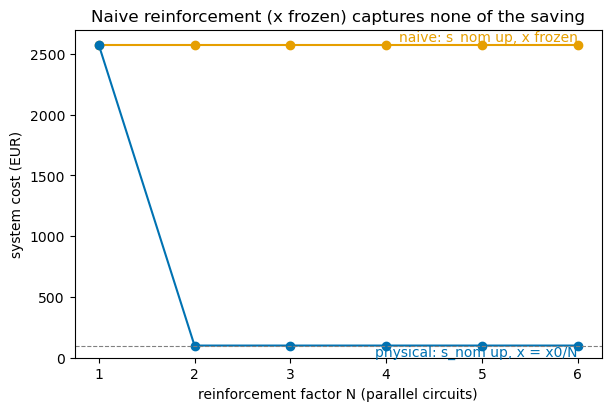

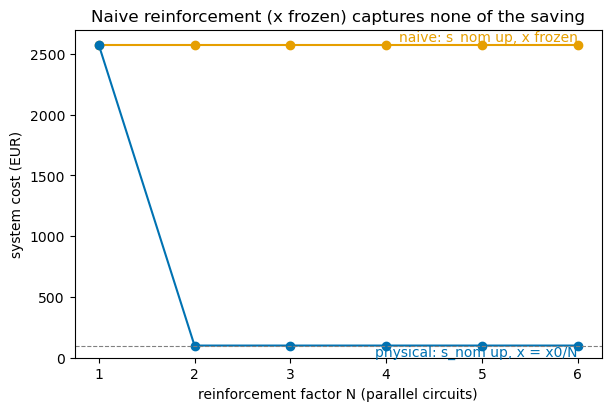

In [8]:
base = sweep.loc[1, "cost_naive"]         # unreinforced system cost
best = sweep["cost_physical"].min()       # best achievable with correct physics
overstated = sweep.loc[4, "cost_naive"] - best

print(f"reinforcement value at stake (base - best achievable): {base - best:.0f} EUR")
print(f"captured by NAIVE    at N=4: {(base - sweep.loc[4, 'cost_naive']) / (base - best):.0%}")
print(f"captured by PHYSICAL at N=4: {(base - sweep.loc[4, 'cost_physical']) / (base - best):.0%}")
print(f"cost overstated by the naive model at N=4: {overstated:.0f} EUR ({overstated / base:.0%})")

assert sweep["cost_naive"].nunique() == 1, "naive should be flat - reinforcement never helps"
assert best < base, "physical reinforcement should lower cost"

fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
ax.plot(sweep.index, sweep.cost_naive, marker="o", color="#E69F00")
ax.plot(sweep.index, sweep.cost_physical, marker="o", color="#0072B2")
ax.axhline(best, ls="--", lw=0.8, color="0.5")
ax.set_xlabel("reinforcement factor N (parallel circuits)")
ax.set_ylabel("system cost (EUR)")
ax.set_ylim(0, None)
ax.set_title("Naive reinforcement (x frozen) captures none of the saving")
ax.annotate("naive: s_nom up, x frozen", (sweep.index[-1], sweep.cost_naive.iloc[-1]),
            color="#E69F00", ha="right", va="bottom")
ax.annotate("physical: s_nom up, x = x0/N", (sweep.index[-1], sweep.cost_physical.iloc[-1]),
            color="#0072B2", ha="right", va="top")
fig

### Interpretation

In this toy the naive reinforcement captures **0 %** of the available saving: the system cost stays at 2575 EUR for every capacity level, because the frozen reactance keeps flow on the congested detour. The physical reinforcement reaches the optimum (100 EUR) from `N = 2` onward. The gap - here **2475 EUR, ~96 % of the base cost** - is the error introduced purely by not scaling `x` with `s_nom`.

Two caveats on magnitude:

- **This is a deterministic single network**, so it measures the reactance error in isolation (the stochastic scenario-0 effect of Section 4 is separate and compounds it).
- **The size is configuration-dependent and here deliberately stark** (the reinforced corridor is the high-reactance one, and the parallel path is tightly capped). In a well-meshed grid with slack the error is smaller, but its *direction* is robust: an `s_nom`-only reinforcement is always too pessimistic about the corridor's value, never too optimistic.

## 6. Does scenario ordering fix it? (proposed mitigation)

Section 4 showed `scenarios[0]` fixes the reactances for the whole ensemble. A natural idea: put the **most expanded** network first, so the reactances are computed from the fully-built grid. Does that solve the problem?

Make the same toy stochastic with two scenarios: `small` (direct corridor `cap=30, x=4`) and `expanded` (`cap=120, x=1`). Solve it twice - once with each scenario first - and read the per-scenario cost. Compare against the *correct* answer: each topology solved on its own reactance (deterministic, Section 5's `solve_toy`).

In [9]:
spec = {"small": dict(cap=30.0, x=4.0), "expanded": dict(cap=120.0, x=1.0)}
COST = {"cheap": 1.0, "backup": 100.0}


def build_stoch(order):
    """Stochastic toy; `order[0]` becomes scenarios[0] and fixes the reactances."""
    m = pypsa.Network()
    m.set_snapshots([0])
    for b in ("1", "2", "3"):
        m.add("Bus", b, v_nom=380.0)
    m.add("Generator", "cheap", bus="1", p_nom=1000, marginal_cost=1.0)
    m.add("Generator", "backup", bus="3", p_nom=1000, marginal_cost=100.0)
    m.add("Load", "load", bus="3", p_set=100.0)
    m.add("Line", "direct", bus0="1", bus1="3", x=4.0, r=0.0, s_nom=30.0)
    m.add("Line", "det_a", bus0="1", bus1="2", x=1.0, r=0.0, s_nom=50.0)
    m.add("Line", "det_b", bus0="2", bus1="3", x=1.0, r=0.0, s_nom=50.0)
    m.set_scenarios({order[0]: 0.5, order[1]: 0.5})
    for sc in order:
        m.lines.loc[(sc, "direct"), "s_nom"] = spec[sc]["cap"]
        m.lines.loc[(sc, "direct"), "x"] = spec[sc]["x"]
    m.optimize(log_to_console=False)
    return m


def scenario_cost(m, sc):
    disp = m.generators_t.p.xs(sc, axis=1, level="scenario").loc[0]
    return sum(disp[g] * COST[g] for g in COST)


rows = []
for order in (["small", "expanded"], ["expanded", "small"]):
    m = build_stoch(order)
    rows.append({
        "scenarios[0]": order[0],
        "x_direct": spec[order[0]]["x"],
        "cost_small": scenario_cost(m, "small"),
        "cost_expanded": scenario_cost(m, "expanded"),
    })
rows.append({
    "scenarios[0]": "per-topology (correct)",
    "x_direct": "own",
    "cost_small": solve_toy(spec["small"]["x"], spec["small"]["cap"])[0],
    "cost_expanded": solve_toy(spec["expanded"]["x"], spec["expanded"]["cap"])[0],
})
cmp = pd.DataFrame(rows).set_index("scenarios[0]").round(1)
cmp["E[cost]"] = (0.5 * (cmp.cost_small + cmp.cost_expanded)).round(1)
cmp

MultiIndex([(   'small', '1'),
            (   'small', '2'),
            (   'small', '3'),
            ('expanded', '1'),
            ('expanded', '2'),
            ('expanded', '3')],
           names=['scenario', 'name'])
MultiIndex([(   'small', 'direct'),
            (   'small',  'det_a'),
            (   'small',  'det_b'),
            ('expanded', 'direct'),
            ('expanded',  'det_a'),
            ('expanded',  'det_b')],
           names=['scenario', 'name'])
MultiIndex([(   'small', 'direct'),
            (   'small',  'det_a'),
            (   'small',  'det_b'),
            ('expanded', 'direct'),
            ('expanded',  'det_a'),
            ('expanded',  'det_b')],
           names=['scenario', 'name'])
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io: Writing time: 0.02s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 10 primals, 28

,x_direct,cost_small,cost_expanded,E[cost]
scenarios[0],,,,
small,4.0,2575.0,2575.0,2575.0
expanded,1.0,5545.0,100.0,2822.5
per-topology (correct),own,2575.0,100.0,1337.5


In [10]:
correct = cmp.loc["per-topology (correct)"]
exp_first = cmp.loc["expanded"]
small_first = cmp.loc["small"]

# "Expanded first" fixes the expanded scenario ...
assert np.isclose(exp_first.cost_expanded, correct.cost_expanded), "expanded not fixed"
# ... but distorts the small scenario, making it worse than the truth.
assert exp_first.cost_small > correct.cost_small, "small scenario not distorted"

print("expanded-first: expanded scenario now CORRECT ({:.0f}), "
      "but small scenario WRONG ({:.0f} vs correct {:.0f})".format(
          exp_first.cost_expanded, exp_first.cost_small, correct.cost_small))
print("neither ordering reproduces the correct E[cost] = {:.0f} "
      "(small-first {:.0f}, expanded-first {:.0f})".format(
          correct["E[cost]"], small_first["E[cost]"], exp_first["E[cost]"]))
print("\n=> Ordering moves the reactance error between scenarios; it does not remove it.")

expanded-first: expanded scenario now CORRECT (100), but small scenario WRONG (5545 vs correct 2575)
neither ordering reproduces the correct E[cost] = 1338 (small-first 2575, expanded-first 2822)

=> Ordering moves the reactance error between scenarios; it does not remove it.


### Interpretation

Putting the expanded network first is **not a clean fix**. It does make the expanded scenario correct (100), but it forces the *small* scenario to use the expanded grid's low reactance: flow then tries to pile onto the small 30 MW corridor, which cannot carry it, so the small scenario's cost jumps from the correct 2575 to 5545. The error is not removed - it is **relocated** from the expanded scenario to the small one, and here it even raises the expected cost.

The reason is fundamental: reactance genuinely differs between topologies, but PyPSA's stochastic KVL can hold only one reactance set. **No ordering recovers the correct per-topology physics.** What does:

- **Separate deterministic solves** per topology (Section 5's `solve_toy`) give each grid its own reactance - correct, but they drop the joint stochastic coupling of the shared here-and-now decision.
- **Choosing `scenarios[0]` deliberately** is still worth doing: pick the topology whose reactances you most need correct (usually the one carrying the decision-relevant flows) and accept a bounded, documented error elsewhere. It is a lesser-evil choice, not a solution.
- **Links** for switchable corridors sidestep reactance entirely - correct only where the device is genuinely controllable (Sections in the companion notes).

## Verdict

PyPSA does **not** drop an `s_nom=0` (or `s_max_pu=0`) AC line from the KVL. The cycle basis is topological (bus0/bus1) and dropped only for infinite impedance, so the stochastic model stays structurally identical across scenarios - well-posed, as required (Sections 1-3).

Consequences:

1. **Phantom cycle.** The zeroed line leaves a spurious KVL coupling on the remaining lines in every scenario where it is "absent". `s_max_pu=0` does not avoid this; only `x=inf` (genuinely dropping the line) does, which is not available per-scenario in a shared-topology stochastic run.
2. **Scenario-0 reactances (Section 4).** Not only the cycle *structure* but also its *weights* come from `scenarios[0]`. A line's own per-scenario reactance is ignored in every other scenario - the whole ensemble is solved on the first scenario's electrical model.
3. **Reactance-not-scaling can be large (Section 5).** Raising `s_nom` without cutting `x` makes flow refuse to use the reinforced corridor. In the toy loop this costs the *entire* reinforcement value (~96 % of base cost). The error is configuration-dependent but always in the pessimistic direction.
4. **Ordering is not a fix (Section 6).** Putting the most-expanded network first corrects that scenario but distorts the others (their small corridors inherit a too-low reactance), and can raise the expected cost. Reactance genuinely differs by topology and PyPSA holds only one set, so no ordering recovers the truth. Choosing `scenarios[0]` deliberately is a documented lesser-evil; the only correct physics comes from separate per-topology deterministic solves, or from modelling switchable corridors as Links where they are genuinely controllable.